In [1]:
!pip install numpy opencv-python tensorflow keras matplotlib scikit-learn

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 1.5 MB/s eta 0:00:27
   - -------------------------------------- 1.0/40.2 MB 1.6 MB/s eta 0:00:25
   - -------------------------------------- 1.6/40.2 MB 1.7 MB/s eta 0:00:23
   - -------------------------------------- 1.8/40.2 MB 1.7 MB/s eta 0:00:23
   -- ------------------------------------- 2.4/40.2 MB 1.8 MB/s eta 0:00:22
   -- ------------------------------------- 2.9/40.2 MB 1.9 MB/s eta 0:00:20
   --- ------------------------------------ 3.4/40.2 MB 2.0 MB/s eta 0:00:19
   ---- ----------------------------------- 4.2/40.2 MB 2.1 MB/s eta 0:00:18
   ---- ----------------------------------- 4.7/40.2 MB 2.2 MB/s eta 0:00:17
   ----- ---------------------------------- 5.2/40.2 MB 2.3 MB/s eta 0:00:16
   ----- -----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.70.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-api-core 2.25.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, but you have protobuf 7.34.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
proto-plus 1.26.1 requires protobuf<7.0.0,>=3.19.0, but you have protobuf 7.34.1 which is incompatible.
streamlit 1.46.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompa

In [2]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

In [3]:
import zipfile

with zipfile.ZipFile("AI_DATA.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Done")

Done


In [4]:
import os
print(os.listdir("dataset"))

['real_and_fake_face', 'real_and_fake_face_detection']


In [5]:
import shutil

shutil.move("dataset/real_and_fake_face/training_real", "dataset/real")
shutil.move("dataset/real_and_fake_face/training_fake", "dataset/fake")

print("Done")

Done


In [6]:
import os
print(os.listdir("dataset"))

['fake', 'real', 'real_and_fake_face', 'real_and_fake_face_detection']


In [8]:
IMG_SIZE = 128

def load_data(path):
    data = []
    labels = []
    
    for label, folder in enumerate(["real", "fake"]):
        folder_path = os.path.join(path, folder)
        
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            
            data.append(img)
            labels.append(label)
    
    return np.array(data), np.array(labels)

X, y = load_data("dataset/")
print("Data shape:", X.shape)

Data shape: (2041, 128, 128, 3)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1632, 128, 128, 3)
Test: (409, 128, 128, 3)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\gudar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 313ms/step - accuracy: 0.5129 - loss: 0.7991 - val_accuracy: 0.5623 - val_loss: 0.6852
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 295ms/step - accuracy: 0.5729 - loss: 0.6784 - val_accuracy: 0.6039 - val_loss: 0.6769
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.6373 - loss: 0.6453 - val_accuracy: 0.6137 - val_loss: 0.6749
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 296ms/step - accuracy: 0.6789 - loss: 0.5878 - val_accuracy: 0.5697 - val_loss: 0.6956
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.7469 - loss: 0.4959 - val_accuracy: 0.5966 - val_loss: 0.7453


In [12]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 302ms/step - accuracy: 0.8272 - loss: 0.3871 - val_accuracy: 0.5721 - val_loss: 0.8472
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 302ms/step - accuracy: 0.8775 - loss: 0.3042 - val_accuracy: 0.5868 - val_loss: 1.0804
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 301ms/step - accuracy: 0.9222 - loss: 0.2025 - val_accuracy: 0.5721 - val_loss: 1.1803
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.9473 - loss: 0.1407 - val_accuracy: 0.5452 - val_loss: 1.3518
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 296ms/step - accuracy: 0.9761 - loss: 0.0827 - val_accuracy: 0.5648 - val_loss: 1.6365
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.9847 - loss: 0.0602 - val_accuracy: 0.6112 - val_loss: 1.7878
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.9865 - loss: 0.0513 - val_accuracy: 0.5306 - val_loss: 2.0804
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - accuracy: 0.9841 - loss: 0.0474 - val_accu

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 39s 686ms/step - accuracy: 0.5110 - loss: 1.6934 - val_accuracy: 0.5623 - val_loss: 0.6890
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 39s 652ms/step - accuracy: 0.5760 - loss: 0.6817 - val_accuracy: 0.5623 - val_loss: 0.6829
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 657ms/step - accuracy: 0.5901 - loss: 0.6817 - val_accuracy: 0.4597 - val_loss: 0.6930
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 662ms/step - accuracy: 0.5766 - loss: 0.6699 - val_accuracy: 0.5623 - val_loss: 0.6873
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 674ms/step - accuracy: 0.5944 - loss: 0.6755 - val_accuracy: 0.5623 - val_loss: 0.7503
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 656ms/step - accuracy: 0.5741 - loss: 0.6722 - val_accuracy: 0.5428 - val_loss: 0.7164
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 42s 667ms/step - accuracy: 0.5778 - loss: 0.6709 - val_accuracy: 0.5746 - val_loss: 0.6888
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 658ms/step - accuracy: 0.5962 - loss: 0.6651 - val_accu

In [18]:
import cv2
import numpy as np

def extract_frames(video_path, max_frames=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame = cv2.resize(frame, (128,128))
        frame = frame / 255.0
        
        frames.append(frame)
    
    cap.release()
    
    return np.array(frames)

In [19]:
frames = extract_frames("sample-1.mp4")
print(frames.shape)

(10, 128, 128, 3)


In [20]:
frames = np.expand_dims(frames, axis=0)
print(frames.shape)

(1, 10, 128, 128, 3)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense

model_lstm = Sequential()

model_lstm.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'), input_shape=(10,128,128,3)))
model_lstm.add(TimeDistributed(MaxPooling2D(2,2)))

model_lstm.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
model_lstm.add(TimeDistributed(MaxPooling2D(2,2)))

model_lstm.add(TimeDistributed(Flatten()))

model_lstm.add(LSTM(50))

model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_lstm.summary()

C:\Users\gudar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\wrapper.py:25: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 10, 126, 126, 32)    │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 10, 63, 63, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 10, 61, 61, 64)      │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 10, 30, 30, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 10, 57600)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 50)                  │      11,530,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,549,643 (44.06 MB)

 Trainable params: 11,549,643 (44.06 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
prediction = model_lstm.predict(frames)

if prediction > 0.5:
    print("Fake Video")
else:
    print("Real Video")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Fake Video


In [23]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show_fft(image_path):
    img = cv2.imread(image_path, 0)  # grayscale
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    
    magnitude = 20 * np.log(np.abs(fshift))
    
    plt.imshow(magnitude, cmap='gray')
    plt.title("FFT Spectrum")
    plt.show()

In [25]:
import os
print(os.listdir("dataset/real")[:10])

['real_00001.jpg', 'real_00002.jpg', 'real_00003.jpg', 'real_00004.jpg', 'real_00005.jpg', 'real_00006.jpg', 'real_00007.jpg', 'real_00008.jpg', 'real_00009.jpg', 'real_00010.jpg']


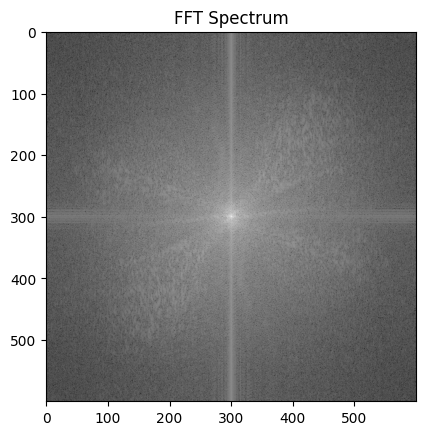

In [ ]:
show_fft("dataset/real/real_00001.jpg")